<a href="https://colab.research.google.com/github/zhangwiki86-soton/L7---Data-Analysis-and-Visualisation/blob/main/DRAFT%20Test%20Glob%20Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Crime Data Analysis of WMP

#Clone files from Github

In [1]:
!pip install panel jupyter_bokeh
!pip install hvplot

In [ ]:
! git clone https://github.com/zhangwiki86-soton/L7---Data-Analysis-and-Visualisation.git
#/content/L7---Data-Analysis-and-Visualisation

#1. Importing Libriaries

In [3]:
import pandas as pd
import glob as glob
import panel as pn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pn.extension(comms='colab')
pn.extension('tabulator')
import hvplot.pandas

#2. Import Data

In [4]:
RawData=glob.glob("/content/L7---Data-Analysis-and-Visualisation/Raw Data/*.csv")
RawData

['/content/L7---Data-Analysis-and-Visualisation/Raw Data/2024-08-west-midlands-street.csv',
 '/content/L7---Data-Analysis-and-Visualisation/Raw Data/2024-06-staffordshire-street.csv',
 '/content/L7---Data-Analysis-and-Visualisation/Raw Data/2024-01-staffordshire-street.csv',
 '/content/L7---Data-Analysis-and-Visualisation/Raw Data/2025-04-staffordshire-street.csv',
 '/content/L7---Data-Analysis-and-Visualisation/Raw Data/2025-02-west-midlands-street.csv',
 '/content/L7---Data-Analysis-and-Visualisation/Raw Data/2024-09-staffordshire-street.csv',
 '/content/L7---Data-Analysis-and-Visualisation/Raw Data/2025-11-staffordshire-street.csv',
 '/content/L7---Data-Analysis-and-Visualisation/Raw Data/2024-04-west-midlands-street.csv',
 '/content/L7---Data-Analysis-and-Visualisation/Raw Data/2025-09-west-midlands-street.csv',
 '/content/L7---Data-Analysis-and-Visualisation/Raw Data/2023-12-west-midlands-street.csv',
 '/content/L7---Data-Analysis-and-Visualisation/Raw Data/2025-04-west-midlands-s

In [5]:
list_df=[]
for csvfile in RawData:
  df=pd.read_csv(csvfile)
  list_df.append(df)

In [ ]:
  list_df

[                                                Crime ID    Month  \
 0                                                    NaN  2024-09   
 1      7a8b7c7f0b8e6f113788e25ec5edf45268fd614ae70307...  2024-09   
 2      620cd472328f788c78bb36d59e58a65fe3df5631692be7...  2024-09   
 3      242dabdcb663b6fc50b7a7cdb5a32c12c6b409fe7d8f1e...  2024-09   
 4      482aa09a8759507ae8fc3ce5e2ae954bec63e0b7695f42...  2024-09   
 ...                                                  ...      ...   
 28630  3e559ffbe453cf0005fad743db1417b72d138cb7b01a41...  2024-09   
 28631  b5f957c2b164d6c66ffbf81986327c3c2d617d067578e3...  2024-09   
 28632  3b9505bd4b4494ffdf4f2461e4440a263de3882cba2c4e...  2024-09   
 28633  19da5c4b9031a11a4efaa9079673f5db77316f69f1e933...  2024-09   
 28634  c418cad2cf5bad06ea7200bce180a07895513d5e2c0b69...  2024-09   
 
                 Reported by          Falls within  Longitude   Latitude  \
 0      West Midlands Police  West Midlands Police  -1.850772  52.588709   
 1    

In [6]:
#Check how many items, expect 24+24=48 of both West Midlands and Staffordshire Police
len(list_df)

48

#Concatenate all CSV into one DataFrame

In [8]:
CrimeData = pd.concat(list_df,axis=0, ignore_index=True) # axis=0 for row concatenation and 1 is for column
CrimeData

,Crime ID,Month,Reported by,Falls within,Longitude,Latitude,Location,LSOA code,LSOA name,Crime type,Last outcome category,Context
0,cf1a136d2275910c8e9b0d29687e8054246369a4d77c62...,2024-08,West Midlands Police,West Midlands Police,-1.845479,52.591165,On or near Four Oaks Common Road,E01009417,Birmingham 001A,Other theft,Unable to prosecute suspect,NaN
1,2f10f0ae45bf44ac7ed5a85d23c26903a1b259ab0e3050...,2024-08,West Midlands Police,West Midlands Police,-1.845479,52.591165,On or near Four Oaks Common Road,E01009417,Birmingham 001A,Public order,Unable to prosecute suspect,NaN
2,a20e6822a461154bb4c87ad7c9091d6b865b086c757a9c...,2024-08,West Midlands Police,West Midlands Police,-1.849790,52.590937,On or near Walsall Road,E01009417,Birmingham 001A,Violence and sexual offences,Court result unavailable,NaN
3,85595ee197c817b504b899e38fc2f63f82bca684cd6a6a...,2024-08,West Midlands Police,West Midlands Police,-1.849790,52.590937,On or near Walsall Road,E01009417,Birmingham 001A,Violence and sexual offences,Court result unavailable,NaN
4,NaN,2024-08,West Midlands Police,West Midlands Police,-1.846312,52.593702,On or near Hook Drive,E01009418,Birmingham 001B,Anti-social behaviour,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
869242,f9f33592adcd10cc7b77a1f9fdb723804bef929918c856...,2024-04,Staffordshire Police,Staffordshire Police,NaN,NaN,No Location,NaN,NaN,Violence and sexual offences,Unable to prosecute suspect,NaN
869243,4bc44876a4d472fc14264cb417e6c9144ebd1003f4ee76...,2024-04,Staffordshire Police,Staffordshire Police,NaN,NaN,No Location,NaN,NaN,Violence and sexual offences,Unable to prosecute suspect,NaN
869244,b2a18955743d6ab6f7808e10602f03d19e88c1724fad2f...,2024-04,Staffordshire Police,Staffordshire Police,NaN,NaN,No Location,NaN,NaN,Violence and sexual offences,Unable to prosecute suspect,NaN
869245,9dad4c0adaba803af2cb2cb4ee305a5ee0825ce624f4f7...,2024-04,Staffordshire Police,Staffordshire Police,NaN,NaN,No Location,NaN,NaN,Violence and sexual offences,Unable to prosecute suspect,NaN


#Structure and Shape

In [9]:
# Dimentions of the DataFrame (number of rows and columns)
CrimeData.shape

(869247, 12)

In [10]:
#CrimeData.index.to_list()
CrimeData.index

RangeIndex(start=0, stop=869247, step=1)

In [11]:
print("colomns:\n", CrimeData.columns) # Column names of the DataFrame
#print("colomns:\n", CrimeData.columns.to_list()) # In list

colomns:
 Index(['Crime ID', 'Month', 'Reported by', 'Falls within', 'Longitude',
       'Latitude', 'Location', 'LSOA code', 'LSOA name', 'Crime type',
       'Last outcome category', 'Context'],
      dtype='object')


In [12]:
# number of rows/records
# any null values in each colum, how complete the columns are populated in the dataset
# what are the types of attributes
CrimeData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 869247 entries, 0 to 869246
Data columns (total 12 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Crime ID               789910 non-null  object 
 1   Month                  869247 non-null  object 
 2   Reported by            869247 non-null  object 
 3   Falls within           869247 non-null  object 
 4   Longitude              868316 non-null  float64
 5   Latitude               868316 non-null  float64
 6   Location               869247 non-null  object 
 7   LSOA code              868316 non-null  object 
 8   LSOA name              868316 non-null  object 
 9   Crime type             869247 non-null  object 
 10  Last outcome category  789910 non-null  object 
 11  Context                0 non-null       float64
dtypes: float64(3), object(9)
memory usage: 79.6+ MB


#Content

In [13]:
CrimeData.head()
CrimeData.tail()

,Crime ID,Month,Reported by,Falls within,Longitude,Latitude,Location,LSOA code,LSOA name,Crime type,Last outcome category,Context
869242,f9f33592adcd10cc7b77a1f9fdb723804bef929918c856...,2024-04,Staffordshire Police,Staffordshire Police,NaN,NaN,No Location,NaN,NaN,Violence and sexual offences,Unable to prosecute suspect,NaN
869243,4bc44876a4d472fc14264cb417e6c9144ebd1003f4ee76...,2024-04,Staffordshire Police,Staffordshire Police,NaN,NaN,No Location,NaN,NaN,Violence and sexual offences,Unable to prosecute suspect,NaN
869244,b2a18955743d6ab6f7808e10602f03d19e88c1724fad2f...,2024-04,Staffordshire Police,Staffordshire Police,NaN,NaN,No Location,NaN,NaN,Violence and sexual offences,Unable to prosecute suspect,NaN
869245,9dad4c0adaba803af2cb2cb4ee305a5ee0825ce624f4f7...,2024-04,Staffordshire Police,Staffordshire Police,NaN,NaN,No Location,NaN,NaN,Violence and sexual offences,Unable to prosecute suspect,NaN
869246,e76a0cdb54b725d22b45c04539d6fc1f8b57efba4e2b5a...,2024-04,Staffordshire Police,Staffordshire Police,NaN,NaN,No Location,NaN,NaN,Violence and sexual offences,Unable to prosecute suspect,NaN


#Detecting missing values

In [14]:
CrimeData.isna()
CrimeData.isnull()
CrimeData.isna().sum()
CrimeData.isnull().sum()

,0
Crime ID,79337
Month,0
Reported by,0
Falls within,0
Longitude,931
Latitude,931
Location,0
LSOA code,931
LSOA name,931
Crime type,0


#Select columns, drop columns not needed

In [16]:
#select Columns needed
CleanData=CrimeData.loc[:, ['Month', 'Reported by','Location','LSOA code','LSOA name','Crime type','Last outcome category']]
CleanData

,Month,Reported by,Location,LSOA code,LSOA name,Crime type,Last outcome category
0,2024-08,West Midlands Police,On or near Four Oaks Common Road,E01009417,Birmingham 001A,Other theft,Unable to prosecute suspect
1,2024-08,West Midlands Police,On or near Four Oaks Common Road,E01009417,Birmingham 001A,Public order,Unable to prosecute suspect
2,2024-08,West Midlands Police,On or near Walsall Road,E01009417,Birmingham 001A,Violence and sexual offences,Court result unavailable
3,2024-08,West Midlands Police,On or near Walsall Road,E01009417,Birmingham 001A,Violence and sexual offences,Court result unavailable
4,2024-08,West Midlands Police,On or near Hook Drive,E01009418,Birmingham 001B,Anti-social behaviour,NaN
...,...,...,...,...,...,...,...
869242,2024-04,Staffordshire Police,No Location,NaN,NaN,Violence and sexual offences,Unable to prosecute suspect
869243,2024-04,Staffordshire Police,No Location,NaN,NaN,Violence and sexual offences,Unable to prosecute suspect
869244,2024-04,Staffordshire Police,No Location,NaN,NaN,Violence and sexual offences,Unable to prosecute suspect
869245,2024-04,Staffordshire Police,No Location,NaN,NaN,Violence and sexual offences,Unable to prosecute suspect


In [17]:
#Double Check if both datasets brought in
CleanData['Reported by'].value_counts()

,count
Reported by,
West Midlands Police,668108
Staffordshire Police,201139


#!!!!!!!!Reference external data here on if these number of Crimes overal reconcil other national statistics;


# Handling Missing Data

In [18]:
CleanData.fillna('Data not recorded', inplace=True) # Fill the blank values with 'data not recorded' for outcome column
CleanData.info() # check if fillna worked

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 869247 entries, 0 to 869246
Data columns (total 7 columns):
 #   Column                 Non-Null Count   Dtype 
---  ------                 --------------   ----- 
 0   Month                  869247 non-null  object
 1   Reported by            869247 non-null  object
 2   Location               869247 non-null  object
 3   LSOA code              869247 non-null  object
 4   LSOA name              869247 non-null  object
 5   Crime type             869247 non-null  object
 6   Last outcome category  869247 non-null  object
dtypes: object(7)
memory usage: 46.4+ MB


In [ ]:
CleanData

,Month,Reported by,Location,LSOA code,LSOA name,Crime type,Last outcome category
0,2024-09,West Midlands Police,On or near Seymour Gardens,E01009417,Birmingham 001A,Anti-social behaviour,Data not recorded
1,2024-09,West Midlands Police,On or near Russell Bank Road,E01009417,Birmingham 001A,Vehicle crime,Unable to prosecute suspect
2,2024-09,West Midlands Police,On or near Walsall Road,E01009417,Birmingham 001A,Vehicle crime,Investigation complete; no suspect identified
3,2024-09,West Midlands Police,On or near Bramble Way,E01009417,Birmingham 001A,Violence and sexual offences,Action to be taken by another organisation
4,2024-09,West Midlands Police,On or near Walsall Road,E01009417,Birmingham 001A,Violence and sexual offences,Investigation complete; no suspect identified
...,...,...,...,...,...,...,...
869242,2024-04,West Midlands Police,On or near Silver Birch Road,E01034315,Wolverhampton 035J,Violence and sexual offences,Investigation complete; no suspect identified
869243,2024-04,West Midlands Police,On or near Pond Grove,E01034315,Wolverhampton 035J,Violence and sexual offences,Court result unavailable
869244,2024-04,West Midlands Police,On or near Rowan Tree Drive,E01034315,Wolverhampton 035J,Violence and sexual offences,Unable to prosecute suspect
869245,2024-04,West Midlands Police,On or near Rowan Tree Drive,E01034315,Wolverhampton 035J,Violence and sexual offences,Unable to prosecute suspect


#Handling Data Quality Issue
Review Crimes and Outcomes, check any duplication/Similar inputs to tidy up

In [19]:
CleanData['Crime type'].value_counts()
CleanData['Last outcome category'].value_counts()

,count
Last outcome category,
Unable to prosecute suspect,396638
Investigation complete; no suspect identified,250736
Data not recorded,79337
Court result unavailable,38529
Local resolution,26314
Awaiting court outcome,22573
Status update unavailable,18453
Under investigation,17037
Action to be taken by another organisation,11528


In [21]:
# Fix typo and duplications
CleanData.replace({"Formal action is not in the public interest":"Further action is not in the public interest"}, inplace=True)
CleanData.replace({"Further investigation is not in the public interest":"Further action is not in the public interest"}, inplace=True)
CleanData['Last outcome category'].value_counts()

,count
Last outcome category,
Unable to prosecute suspect,396638
Investigation complete; no suspect identified,250736
Data not recorded,79337
Court result unavailable,38529
Local resolution,26314
Awaiting court outcome,22573
Status update unavailable,18453
Under investigation,17037
Action to be taken by another organisation,11528


#1.   Bring in two workforce data
#2.   Import LSOA data in one sheet
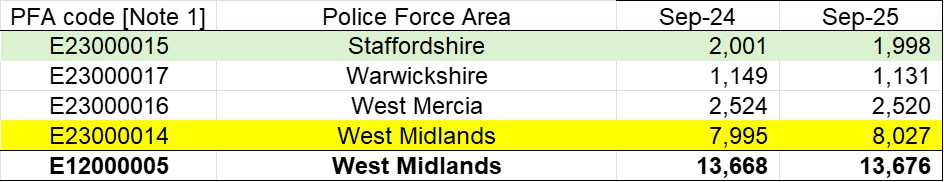


In [22]:
#Create DataFrame FTE
FTE={
    'Reported by': ['West Midlands Police', 'Staffordshire Police'],
        'Police FTE': ['8027',	'1998']}
WorkForceFTE = pd.DataFrame(FTE)
WorkForceFTE

,Reported by,Police FTE
0,West Midlands Police,8027
1,Staffordshire Police,1998


#Merge supplimentary datasets
Append Police Work Force Data and LSOA data to main crime data

In [23]:
#Bring in IMD Scores and LSOA population data
LSOAdata=pd.read_excel("/content/L7---Data-Analysis-and-Visualisation/Raw Data/2025_All_Ranks_Scores_Deciles_Population_Denominators.xlsx")
LSOAdata

,LSOA code (2021),LSOA name (2021),Local Authority District code (2024),Local Authority District name (2024),Index of Multiple Deprivation (IMD) Score,Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived),Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs),Income Score (rate),Income Rank (where 1 is most deprived),Income Decile (where 1 is most deprived 10% of LSOAs),Employment Score (rate),Employment Rank (where 1 is most deprived),Employment Decile (where 1 is most deprived 10% of LSOAs),"Education, Skills and Training Score","Education, Skills and Training Rank (where 1 is most deprived)","Education, Skills and Training Decile (where 1 is most deprived 10% of LSOAs)",Population LSOA
0,E01000001,City of London 001A,E09000001,City of London,8.742,26525,8,0.013,33730,10,0.014,33708,10,0.004,33755,10,2172
1,E01000002,City of London 001B,E09000001,City of London,4.722,31203,10,0.018,33669,10,0.010,33734,10,0.169,33672,10,2044
2,E01000003,City of London 001C,E09000001,City of London,9.250,25913,8,0.107,25167,8,0.064,26985,8,3.269,30273,9,2444
3,E01000005,City of London 001E,E09000001,City of London,19.884,14807,5,0.211,14836,5,0.104,17911,6,17.852,15886,5,2391
4,E01000006,Barking and Dagenham 016A,E09000002,Barking and Dagenham,25.307,10917,4,0.343,7519,3,0.120,15286,5,25.442,11134,4,1930
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33750,E01035758,Vale of White Horse 014H,E07000180,Vale of White Horse,7.945,27536,9,0.101,25934,8,0.074,24575,8,10.893,21842,7,1216
33751,E01035759,Vale of White Horse 015G,E07000180,Vale of White Horse,7.622,27902,9,0.097,26440,8,0.081,22891,7,7.528,25326,8,1592
33752,E01035760,Vale of White Horse 015H,E07000180,Vale of White Horse,7.946,27532,9,0.170,18127,6,0.067,26383,8,10.064,22625,7,1827
33753,E01035761,Vale of White Horse 015I,E07000180,Vale of White Horse,6.682,28981,9,0.136,21596,7,0.054,29547,9,8.482,24267,8,1955


In [24]:
#Observe data for outliers or potential data quality issue
LSOAdata.describe().round(1)
#LSOAdata['Education, Skills and Training Score'].describe().round(1)

,Index of Multiple Deprivation (IMD) Score,Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived),Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs),Income Score (rate),Income Rank (where 1 is most deprived),Income Decile (where 1 is most deprived 10% of LSOAs),Employment Score (rate),Employment Rank (where 1 is most deprived),Employment Decile (where 1 is most deprived 10% of LSOAs),"Education, Skills and Training Score","Education, Skills and Training Rank (where 1 is most deprived)","Education, Skills and Training Decile (where 1 is most deprived 10% of LSOAs)",Population LSOA
count,33755.0,33755.0,33755.0,33755.0,33755.0,33755.0,33755.0,33755.0,33755.0,33755.0,33755.0,33755.0,33755.0
mean,21.7,16878.0,5.5,0.2,16878.0,5.5,0.1,16878.0,5.5,21.7,16878.0,5.5,1736.6
std,15.7,9744.4,2.9,0.2,9744.4,2.9,0.1,9744.4,2.9,18.1,9744.4,2.9,418.8
min,0.2,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,935.0
25%,9.7,8439.5,3.0,0.1,8439.5,3.0,0.1,8439.5,3.0,7.5,8439.5,3.0,1466.0
50%,17.4,16878.0,6.0,0.2,16878.0,6.0,0.1,16878.0,6.0,16.5,16878.0,6.0,1650.0
75%,29.7,25316.5,8.0,0.3,25316.5,8.0,0.2,25316.5,8.0,31.2,25316.5,8.0,1913.0
max,94.2,33755.0,10.0,1.0,33755.0,10.0,1.0,33755.0,10.0,99.6,33755.0,10.0,9947.0


#Keep relevant columns from LSOA data

In [27]:
#select Columns needed
LSOAdataclean=LSOAdata.loc[:, ['LSOA code (2021)','Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs)','Income Decile (where 1 is most deprived 10% of LSOAs)','Employment Decile (where 1 is most deprived 10% of LSOAs)','Education, Skills and Training Decile (where 1 is most deprived 10% of LSOAs)','Population LSOA']]
#Rename Column for easy merge
LSOAdataclean.rename(columns={'LSOA code (2021)':'LSOA code'}, inplace=True)
LSOAdataclean

,LSOA code,Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs),Income Decile (where 1 is most deprived 10% of LSOAs),Employment Decile (where 1 is most deprived 10% of LSOAs),"Education, Skills and Training Decile (where 1 is most deprived 10% of LSOAs)",Population LSOA
0,E01000001,8,10,10,10,2172
1,E01000002,10,10,10,10,2044
2,E01000003,8,8,8,9,2444
3,E01000005,5,5,6,5,2391
4,E01000006,4,3,5,4,1930
...,...,...,...,...,...,...
33750,E01035758,9,8,8,7,1216
33751,E01035759,9,8,7,8,1592
33752,E01035760,9,6,8,7,1827
33753,E01035761,9,7,9,8,1955


#Merge all datasets

In [28]:
#Merge LSOA data
DataMerge1=pd.merge(CleanData,LSOAdataclean,on='LSOA code',how='left')
#Merge workforce data
DataMerge=pd.merge(DataMerge1,WorkForceFTE,on='Reported by',how='left')
DataMerge

,Month,Reported by,Location,LSOA code,LSOA name,Crime type,Last outcome category,Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs),Income Decile (where 1 is most deprived 10% of LSOAs),Employment Decile (where 1 is most deprived 10% of LSOAs),"Education, Skills and Training Decile (where 1 is most deprived 10% of LSOAs)",Population LSOA,Police FTE
0,2024-08,West Midlands Police,On or near Four Oaks Common Road,E01009417,Birmingham 001A,Other theft,Unable to prosecute suspect,9.0,8.0,8.0,9.0,1554.0,8027
1,2024-08,West Midlands Police,On or near Four Oaks Common Road,E01009417,Birmingham 001A,Public order,Unable to prosecute suspect,9.0,8.0,8.0,9.0,1554.0,8027
2,2024-08,West Midlands Police,On or near Walsall Road,E01009417,Birmingham 001A,Violence and sexual offences,Court result unavailable,9.0,8.0,8.0,9.0,1554.0,8027
3,2024-08,West Midlands Police,On or near Walsall Road,E01009417,Birmingham 001A,Violence and sexual offences,Court result unavailable,9.0,8.0,8.0,9.0,1554.0,8027
4,2024-08,West Midlands Police,On or near Hook Drive,E01009418,Birmingham 001B,Anti-social behaviour,Data not recorded,5.0,5.0,4.0,8.0,1615.0,8027
...,...,...,...,...,...,...,...,...,...,...,...,...,...
869242,2024-04,Staffordshire Police,No Location,Data not recorded,Data not recorded,Violence and sexual offences,Unable to prosecute suspect,NaN,NaN,NaN,NaN,NaN,1998
869243,2024-04,Staffordshire Police,No Location,Data not recorded,Data not recorded,Violence and sexual offences,Unable to prosecute suspect,NaN,NaN,NaN,NaN,NaN,1998
869244,2024-04,Staffordshire Police,No Location,Data not recorded,Data not recorded,Violence and sexual offences,Unable to prosecute suspect,NaN,NaN,NaN,NaN,NaN,1998
869245,2024-04,Staffordshire Police,No Location,Data not recorded,Data not recorded,Violence and sexual offences,Unable to prosecute suspect,NaN,NaN,NaN,NaN,NaN,1998


#Creat months group for first and second 12 months for "Year on Year" comparision

In [29]:
#change data type for Column "Month"
DataMerge['Month'] = pd.to_datetime(DataMerge['Month'])
start_date = pd.to_datetime('2023-12')
end_date = pd.to_datetime('2024-11')
DataMerge['Month Group'] = DataMerge['Month'].apply(lambda x: 'first 12 months' if (x >= start_date and x <= end_date) else 'second 12 months')
DataMerge

,Month,Reported by,Location,LSOA code,LSOA name,Crime type,Last outcome category,Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs),Income Decile (where 1 is most deprived 10% of LSOAs),Employment Decile (where 1 is most deprived 10% of LSOAs),"Education, Skills and Training Decile (where 1 is most deprived 10% of LSOAs)",Population LSOA,Police FTE,Month Group
0,2024-08-01,West Midlands Police,On or near Four Oaks Common Road,E01009417,Birmingham 001A,Other theft,Unable to prosecute suspect,9.0,8.0,8.0,9.0,1554.0,8027,first 12 months
1,2024-08-01,West Midlands Police,On or near Four Oaks Common Road,E01009417,Birmingham 001A,Public order,Unable to prosecute suspect,9.0,8.0,8.0,9.0,1554.0,8027,first 12 months
2,2024-08-01,West Midlands Police,On or near Walsall Road,E01009417,Birmingham 001A,Violence and sexual offences,Court result unavailable,9.0,8.0,8.0,9.0,1554.0,8027,first 12 months
3,2024-08-01,West Midlands Police,On or near Walsall Road,E01009417,Birmingham 001A,Violence and sexual offences,Court result unavailable,9.0,8.0,8.0,9.0,1554.0,8027,first 12 months
4,2024-08-01,West Midlands Police,On or near Hook Drive,E01009418,Birmingham 001B,Anti-social behaviour,Data not recorded,5.0,5.0,4.0,8.0,1615.0,8027,first 12 months
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
869242,2024-04-01,Staffordshire Police,No Location,Data not recorded,Data not recorded,Violence and sexual offences,Unable to prosecute suspect,NaN,NaN,NaN,NaN,NaN,1998,first 12 months
869243,2024-04-01,Staffordshire Police,No Location,Data not recorded,Data not recorded,Violence and sexual offences,Unable to prosecute suspect,NaN,NaN,NaN,NaN,NaN,1998,first 12 months
869244,2024-04-01,Staffordshire Police,No Location,Data not recorded,Data not recorded,Violence and sexual offences,Unable to prosecute suspect,NaN,NaN,NaN,NaN,NaN,1998,first 12 months
869245,2024-04-01,Staffordshire Police,No Location,Data not recorded,Data not recorded,Violence and sexual offences,Unable to prosecute suspect,NaN,NaN,NaN,NaN,NaN,1998,first 12 months


#Analysis and Visualisation

#Need to be able to have view for WMP and SP both

https://www.plumplot.co.uk/West-Midlands-drugs-crime-statistics.html#:~:text=West%20Midlands%20drugs%20crime%20rate%20compared%20to%20other%20regions,annual%20change%2C%20crime%20is%20increasing

# 1. Is West Midlands Police's performance improving over the 24 months time - compare the first 12 months and the second 12 months

In [31]:
# Data transformation
crime_counts = DataMerge.groupby(['Reported by','Month Group']).size().reset_index(name='CrimeCount')
crime_counts

,Reported by,Month Group,CrimeCount
0,Staffordshire Police,first 12 months,99527
1,Staffordshire Police,second 12 months,101612
2,West Midlands Police,first 12 months,344501
3,West Midlands Police,second 12 months,323607


##1.1 West Midlands Crime Decreased by 6.1% from the first 12 months to the second 12 months. At the same time, staffordshire police saw increase of crime

In [32]:
#Pivot crime_counts table, use 'Month Group' as column headers
crime_counts_pivot = crime_counts.pivot_table(index='Reported by', columns='Month Group', values='CrimeCount').reset_index()
crime_counts_pivot.columns.name = None # Remove the 'Month Group' name

#Calculate variance of the first 12 months and second 12 months
crime_counts_pivot ['Variance %'] =(crime_counts_pivot['second 12 months']-crime_counts_pivot['first 12 months'])/crime_counts_pivot['first 12 months']*100
crime_counts_pivot ['Variance %'] = crime_counts_pivot['Variance %'].round(1)
crime_counts_pivot

,Reported by,first 12 months,second 12 months,Variance %
0,Staffordshire Police,99527.0,101612.0,2.1
1,West Midlands Police,344501.0,323607.0,-6.1


In [50]:
#Which LSOA is the worst, any chance over the Year on Year

# West Midlands Police
# Variance number of crimes by types
crime_counts_type_wmp = DataMerge.groupby(['LSOA name','Month Group','Reported by']).size().reset_index(name='CrimeCount')
crime_counts_type_wmp
crime_counts_type_wmp=crime_counts_type_wmp[crime_counts_type_wmp['Reported by'] == 'West Midlands Police']
#Pivot the table use 'Month Group' as column headers
crime_counts_pivot1 = crime_counts_type_wmp.pivot_table(index='LSOA name', columns='Month Group',values='CrimeCount').reset_index()
crime_counts_pivot1.columns.name = None # Remove the 'Month Group' column name

#Calculate variance of the first 12 months and second 12 months
crime_counts_pivot1 ['Variance %'] =(crime_counts_pivot1['second 12 months']-crime_counts_pivot1['first 12 months'])/crime_counts_pivot1['first 12 months']*100
crime_counts_pivot1 ['Variance %'] = crime_counts_pivot1['Variance %'].round(1)
#crime_counts_pivot1.head(10)
crime_counts_pivot1.sort_values(by=["second 12 months"],ascending=False).head(10)
#crime_counts_pivot1.sort_values(by=["Variance %"],ascending=True)

,LSOA name,first 12 months,second 12 months,Variance %
629,Birmingham 138A,5751.0,6246.0,8.6
1546,Walsall 030A,2442.0,2259.0,-7.5
809,Coventry 031E,2043.0,2241.0,9.7
614,Birmingham 135C,2330.0,1928.0,-17.3
236,Birmingham 050E,1863.0,1916.0,2.8
1695,Wolverhampton 020H,1964.0,1887.0,-3.9
237,Birmingham 050F,2124.0,1704.0,-19.8
810,Coventry 031F,1983.0,1670.0,-15.8
1314,Solihull 009A,1584.0,1373.0,-13.3
155,Birmingham 033F,1172.0,1232.0,5.1


In [51]:
#Which Location is the worst, any chance over the Year on Year

# West Midlands Police
# Variance number of crimes by types
crime_counts_type_wmp = DataMerge.groupby(['Location','Month Group','Reported by']).size().reset_index(name='CrimeCount')
crime_counts_type_wmp
crime_counts_type_wmp=crime_counts_type_wmp[crime_counts_type_wmp['Reported by'] == 'West Midlands Police']
#Pivot the table use 'Month Group' as column headers
crime_counts_pivot1 = crime_counts_type_wmp.pivot_table(index='Location', columns='Month Group',values='CrimeCount').reset_index()
crime_counts_pivot1.columns.name = None # Remove the 'Month Group' column name

#Calculate variance of the first 12 months and second 12 months
crime_counts_pivot1 ['Variance %'] =(crime_counts_pivot1['second 12 months']-crime_counts_pivot1['first 12 months'])/crime_counts_pivot1['first 12 months']*100
crime_counts_pivot1 ['Variance %'] = crime_counts_pivot1['Variance %'].round(1)
#crime_counts_pivot1.head(10)
crime_counts_pivot1.sort_values(by=["second 12 months"],ascending=False).head(10)
#crime_counts_pivot1.sort_values(by=["Variance %"],ascending=True)

,Location,first 12 months,second 12 months,Variance %
13043,On or near Parking Area,16164.0,15585.0,-3.6
16438,On or near Supermarket,15568.0,14757.0,-5.2
13358,On or near Petrol Station,9582.0,8987.0,-6.2
15332,On or near Shopping Area,9464.0,8918.0,-5.8
8859,On or near Hospital,2815.0,2560.0,-9.1
15736,On or near Sports/Recreation Area,2134.0,2345.0,9.9
8392,On or near High Street,2074.0,2070.0,-0.2
12277,On or near Nightclub,2126.0,1705.0,-19.8
6766,On or near Further/Higher Educational Building,1833.0,1546.0,-15.7
12163,On or near New Street,1307.0,1344.0,2.8


##1.2 Which type of crime presented the biggest change over the observed period (first 12 months vs the second 12 months) -  West Midlands and Staffordshore Police respectively

In [36]:
# West Midlands Police
# Variance number of crimes by types
crime_counts_type_wmp = DataMerge.groupby(['Crime type','Month Group','Reported by']).size().reset_index(name='CrimeCount')
crime_counts_type_wmp
crime_counts_type_wmp=crime_counts_type_wmp[crime_counts_type_wmp['Reported by'] == 'West Midlands Police']
#Pivot the table use 'Month Group' as column headers
crime_counts_pivot1 = crime_counts_type_wmp.pivot_table(index='Crime type', columns='Month Group',values='CrimeCount').reset_index()
crime_counts_pivot1.columns.name = None # Remove the 'Month Group' column name

#Calculate variance of the first 12 months and second 12 months
crime_counts_pivot1 ['Variance %'] =(crime_counts_pivot1['second 12 months']-crime_counts_pivot1['first 12 months'])/crime_counts_pivot1['first 12 months']*100
crime_counts_pivot1 ['Variance %'] = crime_counts_pivot1['Variance %'].round(1)
crime_counts_pivot1.sort_values(by=["Variance %"],ascending=False)

,Crime type,first 12 months,second 12 months,Variance %
4,Drugs,7728.0,9277.0,20.0
10,Shoplifting,30229.0,32263.0,6.7
7,Possession of weapons,6356.0,6590.0,3.7
13,Violence and sexual offences,135136.0,131446.0,-2.7
3,Criminal damage and arson,25711.0,24600.0,-4.3
5,Other crime,6782.0,6427.0,-5.2
11,Theft from the person,2950.0,2663.0,-9.7
1,Bicycle theft,2011.0,1811.0,-9.9
8,Public order,19995.0,17464.0,-12.7
0,Anti-social behaviour,27784.0,23883.0,-14.0


In [37]:
# Staffordshire Police
# Variance number of crimes by types
crime_counts_type_sp = DataMerge.groupby(['Crime type','Month Group','Reported by']).size().reset_index(name='CrimeCount')
crime_counts_type_sp
crime_counts_type_sp=crime_counts_type_sp[crime_counts_type_sp['Reported by'] == 'Staffordshire Police']
#Pivot the table use 'Month Group' as column headers
crime_counts_pivot2 = crime_counts_type_sp.pivot_table(index='Crime type', columns='Month Group',values='CrimeCount').reset_index()
crime_counts_pivot2.columns.name = None # Remove the 'Month Group' column name

#Calculate variance of the first 12 months and second 12 months
crime_counts_pivot2 ['Variance %'] =(crime_counts_pivot2['second 12 months']-crime_counts_pivot2['first 12 months'])/crime_counts_pivot2['first 12 months']*100
crime_counts_pivot2 ['Variance %'] = crime_counts_pivot2['Variance %'].round(1)
crime_counts_pivot2.sort_values(by=["Variance %"],ascending=False)


,Crime type,first 12 months,second 12 months,Variance %
4,Drugs,1926.0,3113.0,61.6
0,Anti-social behaviour,12414.0,15256.0,22.9
9,Robbery,826.0,1000.0,21.1
5,Other crime,1987.0,2320.0,16.8
7,Possession of weapons,1085.0,1159.0,6.8
8,Public order,8254.0,8450.0,2.4
13,Violence and sexual offences,40721.0,41009.0,0.7
10,Shoplifting,7380.0,6991.0,-5.3
3,Criminal damage and arson,7740.0,7193.0,-7.1
12,Vehicle crime,5209.0,4758.0,-8.7


In [38]:
MergeCompare=pd.merge(crime_counts_pivot1,crime_counts_pivot2,on='Crime type',how='left')
MergeCompare=MergeCompare.loc[:, ['Crime type','Variance %_x','Variance %_y']]
MergeCompare.rename(columns={'Variance %_x':'Variance % West Midlands Police','Variance %_y':'Variance % Staffordshire Police'}, inplace=True)
MergeCompare

,Crime type,Variance % West Midlands Police,Variance % Staffordshire Police
0,Anti-social behaviour,-14.0,22.9
1,Bicycle theft,-9.9,-9.7
2,Burglary,-17.6,-20.6
3,Criminal damage and arson,-4.3,-7.1
4,Drugs,20.0,61.6
5,Other crime,-5.2,16.8
6,Other theft,-15.2,-9.0
7,Possession of weapons,3.7,6.8
8,Public order,-12.7,2.4
9,Robbery,-15.0,21.1


In [42]:
MergeCompare_unpivoted = pd.melt(MergeCompare, id_vars=['Crime type'], value_vars=['Variance % West Midlands Police', 'Variance % Staffordshire Police'], var_name='Police Force', value_name='Variance %')
MergeCompare_unpivoted

,Crime type,Police Force,Variance %
0,Anti-social behaviour,Variance % West Midlands Police,-14.0
1,Bicycle theft,Variance % West Midlands Police,-9.9
2,Burglary,Variance % West Midlands Police,-17.6
3,Criminal damage and arson,Variance % West Midlands Police,-4.3
4,Drugs,Variance % West Midlands Police,20.0
5,Other crime,Variance % West Midlands Police,-5.2
6,Other theft,Variance % West Midlands Police,-15.2
7,Possession of weapons,Variance % West Midlands Police,3.7
8,Public order,Variance % West Midlands Police,-12.7
9,Robbery,Variance % West Midlands Police,-15.0


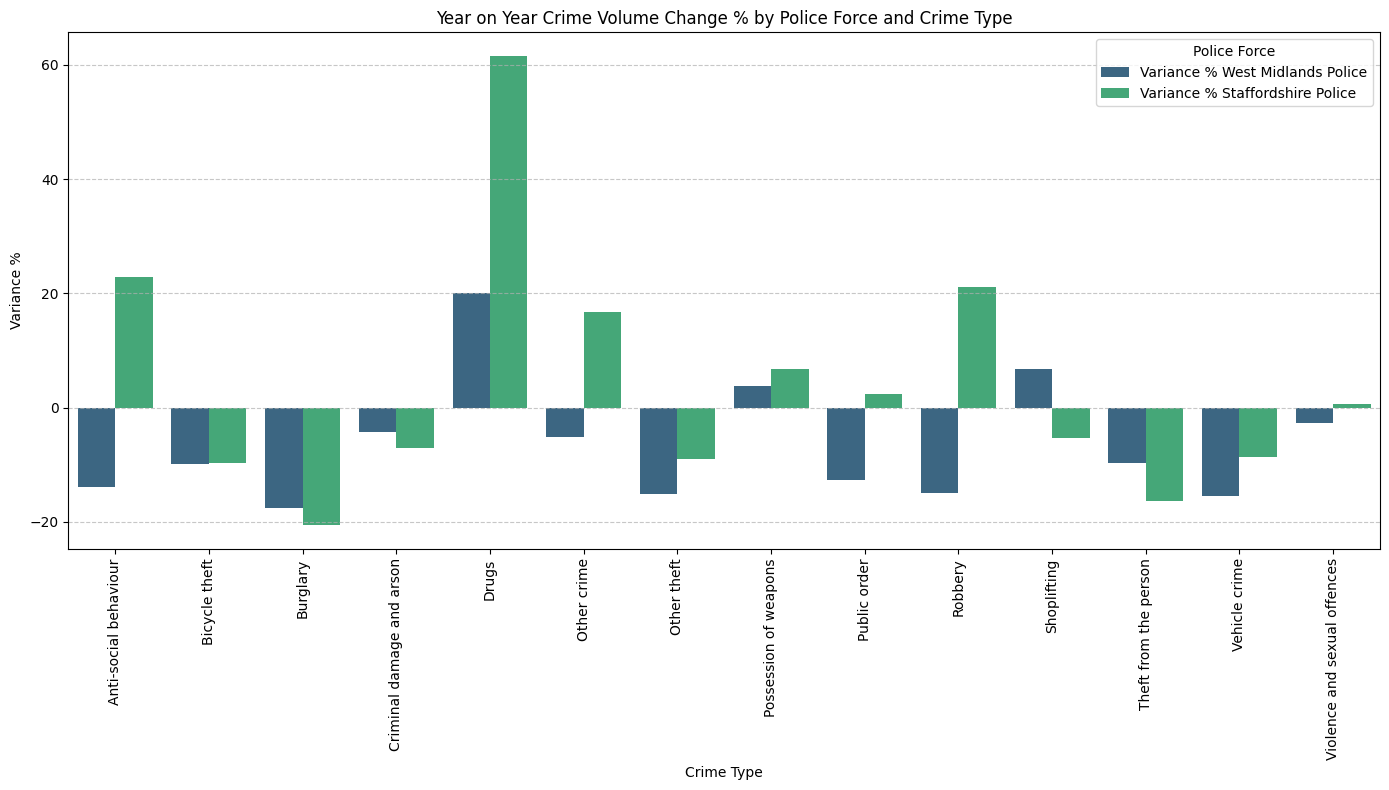

In [43]:
plt.figure(figsize=(14, 8))
sns.barplot(x='Crime type', y='Variance %', hue='Police Force', data=MergeCompare_unpivoted, palette='viridis')
plt.title('Year on Year Crime Volume Change % by Police Force and Crime Type')
plt.xlabel('Crime Type')
plt.ylabel('Variance %')
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#There are 7.7% and 13.8% of crimes did not have an outcome recorded for West Midlands and staffordshire police repectively, this could potentially skewed the insights, for instance, unproscuted proportion could be even higher or lower than West Midland Police area.

#Creat Radio Botton for Police Force names

In [ ]:
#Prepare data for pipeline
crime_over_time = DataMerge[['Reported by','Crime type','Month']].value_counts().reset_index(name='Count')
display(crime_over_time)
crime_over_time = crime_over_time.interactive()

,Reported by,Crime type,Month,Count
0,West Midlands Police,Violence and sexual offences,2024-05-01,12342
1,West Midlands Police,Violence and sexual offences,2025-07-01,12230
2,West Midlands Police,Violence and sexual offences,2024-07-01,12226
3,West Midlands Police,Violence and sexual offences,2025-06-01,11895
4,West Midlands Police,Violence and sexual offences,2024-06-01,11862
...,...,...,...,...
667,Staffordshire Police,Theft from the person,2025-06-01,18
668,Staffordshire Police,Theft from the person,2025-05-01,17
669,Staffordshire Police,Theft from the person,2024-03-01,15
670,Staffordshire Police,Theft from the person,2025-09-01,13


In [ ]:
#crime_over_time_pivot_full = crime_over_time.pivot_table(index=['Month', 'Crime type'], columns='Reported by', values='Count').reset_index()
crime_over_time_pivot_full = crime_over_time.pivot_table(index=['Month', 'Reported by'], columns='Crime type', values='Count').reset_index()
crime_over_time_pivot_full.columns.name = None # Remove the column name for clarity
display(crime_over_time_pivot_full)

In [ ]:
#Creat Radio button for interation with data
yaxis_police = pn.widgets.RadioButtonGroup(
    name='Count of Crime',
    options=['Anti-social behaviour','Bicycle theft','Burglary','Criminal damage and arson','Drugs','Other crime','Other theft','Possession of weapons','Public order','Robbery','Shoplifting','Theft from the person','Vehicle crime','Violence and sexual offences'],
    button_type='primary',
    button_style='outline'
    )
yaxis_police

RadioButtonGroup(button_style='outline', button_type='primary', name='Count of Crime', options=['Anti-social behaviour', ...], value='Anti-social behaviour')

In [ ]:
#Creat Pipeline
crime_pipeline =(
    crime_over_time_pivot_full
    .groupby(['Reported by','Month'])[yaxis_police].sum()
    .reset_index()
    .sort_values(by='Month')
    .reset_index(drop=True)
                 )
crime_pipeline

##Seasonal trend over 24 months - Interactive chart like dashboard, with radio buttons for filtering

In [ ]:
crime_plot=crime_pipeline.hvplot(x='Month', by='Reported by', y=yaxis_police, line_width=2, width=1500, height=500, title ="Crime over time")
crime_plot

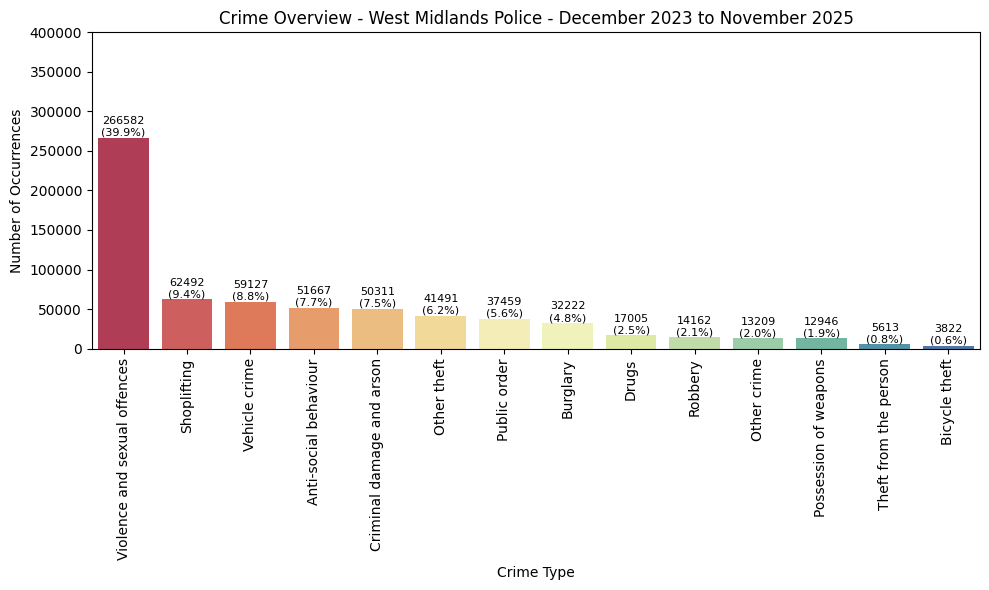

In [ ]:
#Bar Chart with percentages of total % For Crime Types
Police=['West Midlands Police']
chart1=CleanData[CleanData['Reported by'].isin(Police)]
crime_type_counts = chart1['Crime type'].value_counts()
total_crimes = crime_type_counts.sum()
crime_type_percentages = (crime_type_counts / total_crimes * 100).round(1)

plt.figure(figsize=(10, 6))
sns.barplot(x=crime_type_counts.index, y=crime_type_counts.values, hue=crime_type_counts.index, palette='Spectral', legend=False)
plt.title('Crime Overview - West Midlands Police - December 2023 to November 2025')
plt.ylim(0, 400000)
plt.xlabel('Crime Type')
plt.ylabel('Number of Occurrences')
plt.xticks(rotation=90) # Rotate labels for better readability

# Add annotations for count and percentage
for index, value in enumerate(crime_type_counts.values):
    percentage = crime_type_percentages.iloc[index]
    plt.text(index, value + 50, f'{value}\n({percentage:.1f}%)', color='black', ha='center', va='bottom', fontsize=8)

# Adjust layout to prevent labels from being cut off
plt.tight_layout()
plt.show()

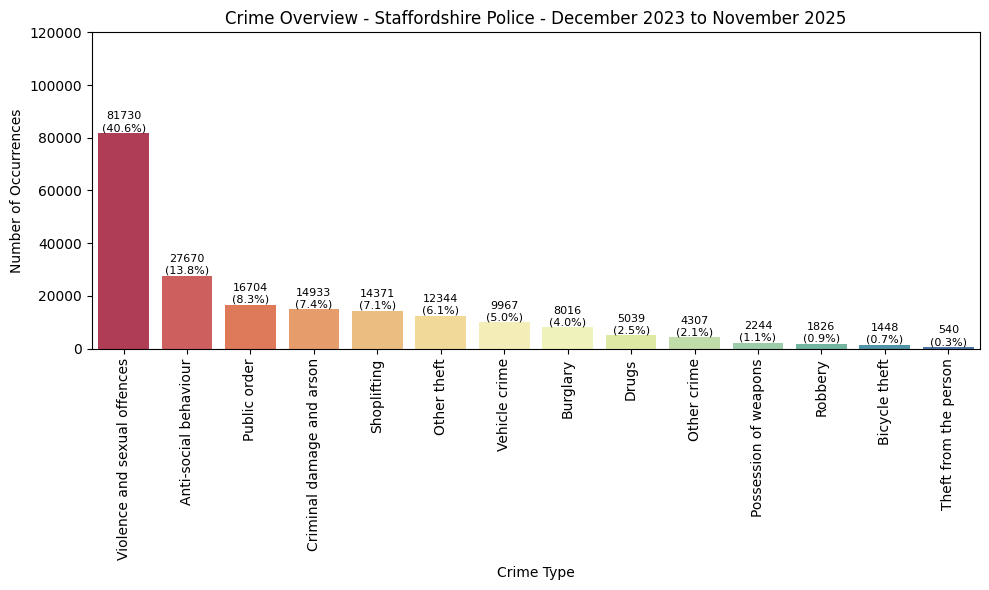

In [ ]:
#Bar Chart with percentages of total % For Crime Types
Police1=['Staffordshire Police']
chart2=CleanData[CleanData['Reported by'].isin(Police1)]
crime_type_counts = chart2['Crime type'].value_counts()
total_crimes = crime_type_counts.sum()
crime_type_percentages = (crime_type_counts / total_crimes * 100).round(1)

plt.figure(figsize=(10, 6))
sns.barplot(x=crime_type_counts.index, y=crime_type_counts.values, hue=crime_type_counts.index, palette='Spectral', legend=False)
plt.title('Crime Overview - Staffordshire Police - December 2023 to November 2025')
plt.ylim(0, 120000)
plt.xlabel('Crime Type')
plt.ylabel('Number of Occurrences')
plt.xticks(rotation=90) # Rotate labels for better readability

# Add annotations for count and percentage
for index, value in enumerate(crime_type_counts.values):
    percentage = crime_type_percentages.iloc[index]
    plt.text(index, value + 50, f'{value}\n({percentage:.1f}%)', color='black', ha='center', va='bottom', fontsize=8)

# Adjust layout to prevent labels from being cut off
plt.tight_layout()
plt.show()

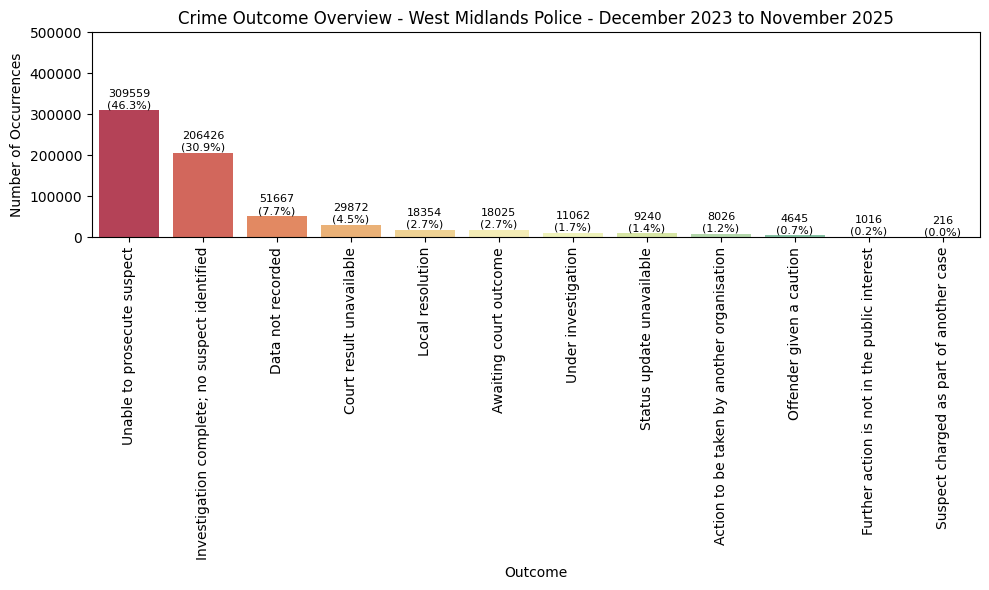

In [ ]:
#Bar Chart with percentages of total %
#Police=['West Midlands Police']
#chart1=CleanData[CleanData['Reported by'].isin(Police)]
outcome_counts = chart1['Last outcome category'].value_counts()
total_crimes = outcome_counts.sum()
outcome_percentages = (outcome_counts / total_crimes * 100).round(1)

plt.figure(figsize=(10, 6))
sns.barplot(x=outcome_counts.index, y=outcome_counts.values, hue=outcome_counts.index, palette='Spectral', legend=False) #viridis
plt.title('Crime Outcome Overview - West Midlands Police - December 2023 to November 2025')
plt.ylim(0, 500000)
plt.xlabel('Outcome')
plt.ylabel('Number of Occurrences')
plt.xticks(rotation=90) # Rotate labels for better readability

# Add annotations for count and percentage
for index, value in enumerate(outcome_counts.values):
    percentage = outcome_percentages.iloc[index]
    plt.text(index, value + 50, f'{value}\n({percentage:.1f}%)', color='black', ha='center', va='bottom', fontsize=8)

# Adjust layout to prevent labels from being cut off
plt.tight_layout()
plt.show()

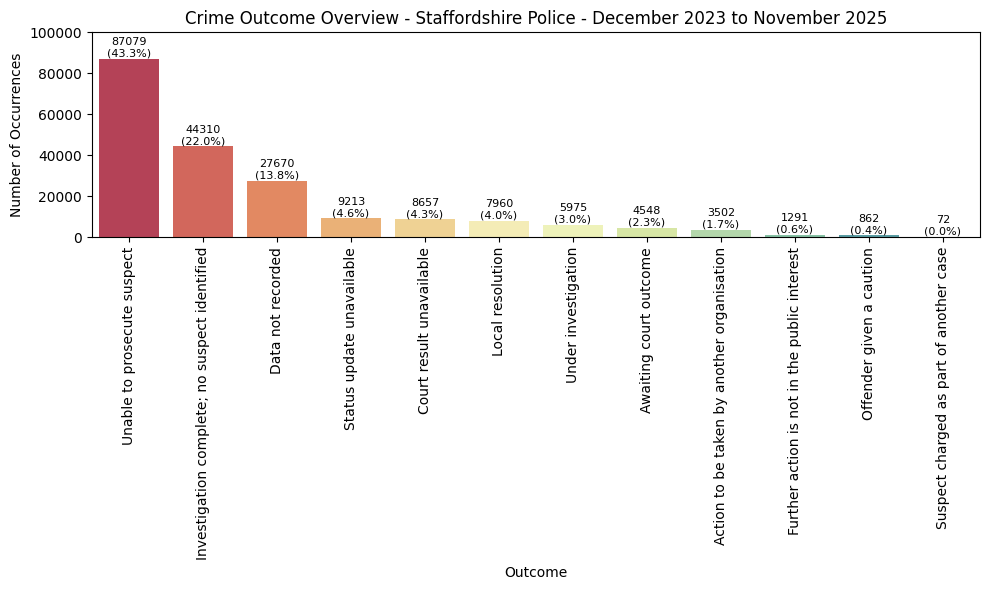

In [ ]:
#Bar Chart with percentages of total %
#Police=['West Midlands Police']
chart2=CleanData[CleanData['Reported by'].isin(Police1)]
outcome_counts = chart2['Last outcome category'].value_counts()
total_crimes = outcome_counts.sum()
outcome_percentages = (outcome_counts / total_crimes * 100).round(1)

plt.figure(figsize=(10, 6))
sns.barplot(x=outcome_counts.index, y=outcome_counts.values, hue=outcome_counts.index, palette='Spectral', legend=False) #viridis
plt.title('Crime Outcome Overview - Staffordshire Police - December 2023 to November 2025')
plt.ylim(0, 100000)
plt.xlabel('Outcome')
plt.ylabel('Number of Occurrences')
plt.xticks(rotation=90) # Rotate labels for better readability

# Add annotations for count and percentage
for index, value in enumerate(outcome_counts.values):
    percentage = outcome_percentages.iloc[index]
    plt.text(index, value + 50, f'{value}\n({percentage:.1f}%)', color='black', ha='center', va='bottom', fontsize=8)

# Adjust layout to prevent labels from being cut off
plt.tight_layout()
plt.show()

#Correlation between LSOA metrics and Crime Rate Per 12 Month/Year, not 24 Months

In [ ]:
crime_counts_lsoa = DataMerge.groupby(['LSOA name','Reported by','Population LSOA','Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs)']).size().reset_index(name='CrimeCount')
crime_counts_lsoa['Weighted Crime/1000 population']=(crime_counts_lsoa['CrimeCount']/crime_counts_lsoa['Population LSOA'].astype(float))*1000/2 # 12 months not total 24 months
crime_counts_lsoa['Weighted Crime/1000 population']=crime_counts_lsoa['Weighted Crime/1000 population'].round(2)
#crime_counts_lsoa.sort_values(by=["Weighted Crime/1000 population"],ascending=False)
crime_counts_lsoa
#Police=['West Midlands Police']
#a=crime_counts_lsoa[crime_counts_lsoa['Reported by'].isin(Police)]
#a
#a.sort_values(by=["Weighted Crime/1000 population"],ascending=False)

,LSOA name,Reported by,Population LSOA,Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs),CrimeCount,Weighted Crime/1000 population
0,Ashfield 001C,Staffordshire Police,1834.0,6.0,1,0.27
1,Ashfield 012B,Staffordshire Police,1399.0,5.0,1,0.36
2,Barking and Dagenham 007D,Staffordshire Police,2109.0,4.0,1,0.24
3,Barnsley 005E,Staffordshire Police,2053.0,8.0,1,0.24
4,Barnsley 007C,Staffordshire Police,1671.0,1.0,1,0.30
...,...,...,...,...,...,...
2941,Wyre Forest 001E,Staffordshire Police,1810.0,2.0,12,3.31
2942,Wyre Forest 001F,Staffordshire Police,2534.0,5.0,1,0.20
2943,Wyre Forest 005C,Staffordshire Police,1855.0,2.0,1,0.27
2944,Wyre Forest 011E,Staffordshire Police,1440.0,3.0,1,0.35


#Creat NEW Column 'Weighted Crime/1000 WTF police' Per Year
#Creat NEW Column 'Weighted Crime/1000 population' Per Year


In [ ]:
b=crime_counts_lsoa.pivot_table(index='Reported by',values="Population LSOA",aggfunc='sum')
c=crime_counts_lsoa.pivot_table(index='Reported by',values="CrimeCount",aggfunc='sum')
e=DataMerge.pivot_table(index='Reported by',values="Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs)",aggfunc='mean')

WorkForceFTE,b,c,e
#merge and calculate weighted data by police
d=pd.merge(c,b,on='Reported by',how='left')
f=pd.merge(d,e,on='Reported by',how='left')
weighted_data=pd.merge(f,WorkForceFTE,on='Reported by',how='left')
weighted_data['Crime/1000 population/12 Months']=(weighted_data['CrimeCount']/weighted_data['Population LSOA'].astype(float))*1000/2
weighted_data['Crime/Police FTE/12 Months']=(weighted_data['CrimeCount']/weighted_data['Police FTE'].astype(float))*1000/2

weighted_data

,Reported by,CrimeCount,Population LSOA,Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs),Police FTE,Crime/1000 population/12 Months,Crime/Police FTE/12 Months
0,Staffordshire Police,200191,2082499.0,4.171666,1998,48.065089,50097.847848
1,West Midlands Police,668108,3113162.0,2.977135,8027,107.303764,41616.295004


#Correlations
##Test of Staffordshire police indeed perform better or West Midlands Deprivation drove it more
#limitation
the LOSA data missing in the dataset, in this project we only assume the outcome based on data available
check if there is a positive correlation bettween deprevation and Crime Rate

In [ ]:
#Calculate R = -0.75, indicate a correlation coefficient of 0.75 suggested negative strong correlation
correlation_deprivation = crime_counts_lsoa.groupby(['Reported by', 'Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs)'])['Weighted Crime/1000 population'].mean().reset_index()
numerical_columns=['Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs)','Weighted Crime/1000 population']
print(correlation_deprivation[numerical_columns].corr().round(2))
#correlation_employment = crime_counts_lsoa1.groupby(['Reported by', 'Employment Decile (where 1 is most deprived 10% of LSOAs)'])['Weighted Crime/1000 population'].mean().reset_index()
#correlation_income = crime_counts_lsoa.groupby(['Reported by', 'Income Decile (where 1 is most deprived 10% of LSOAs)'])['Weighted Crime/1000 population'].mean().reset_index()


                                                    Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs)  \
Index of Multiple Deprivation (IMD) Decile (whe...                                               1.00                                    
Weighted Crime/1000 population                                                                  -0.75                                    

                                                    Weighted Crime/1000 population  
Index of Multiple Deprivation (IMD) Decile (whe...                           -0.75  
Weighted Crime/1000 population                                                1.00  


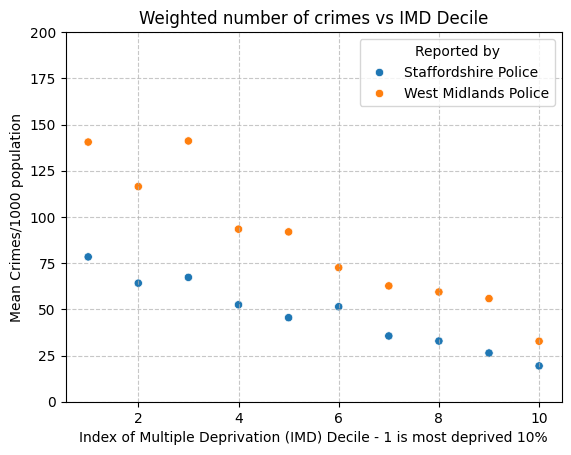

In [ ]:
sns.scatterplot(data=correlation_deprivation, x="Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs)", y="Weighted Crime/1000 population", hue="Reported by")
plt.title('Weighted number of crimes vs IMD Decile')
plt.xlabel('Index of Multiple Deprivation (IMD) Decile - 1 is most deprived 10%')
plt.ylabel('Mean Crimes/1000 population')
plt.grid(True, linestyle='--', alpha=0.7)
plt.ylim(0, 200)
plt.show()

In [ ]:
educatiom_imd_correlation=LSOAdata.loc[:, ['Index of Multiple Deprivation (IMD) Score','Education, Skills and Training Score']]
educatiom_imd_correlation.corr().round(2)

,Index of Multiple Deprivation (IMD) Score,"Education, Skills and Training Score"
Index of Multiple Deprivation (IMD) Score,1.00,0.89
"Education, Skills and Training Score",0.89,1.00


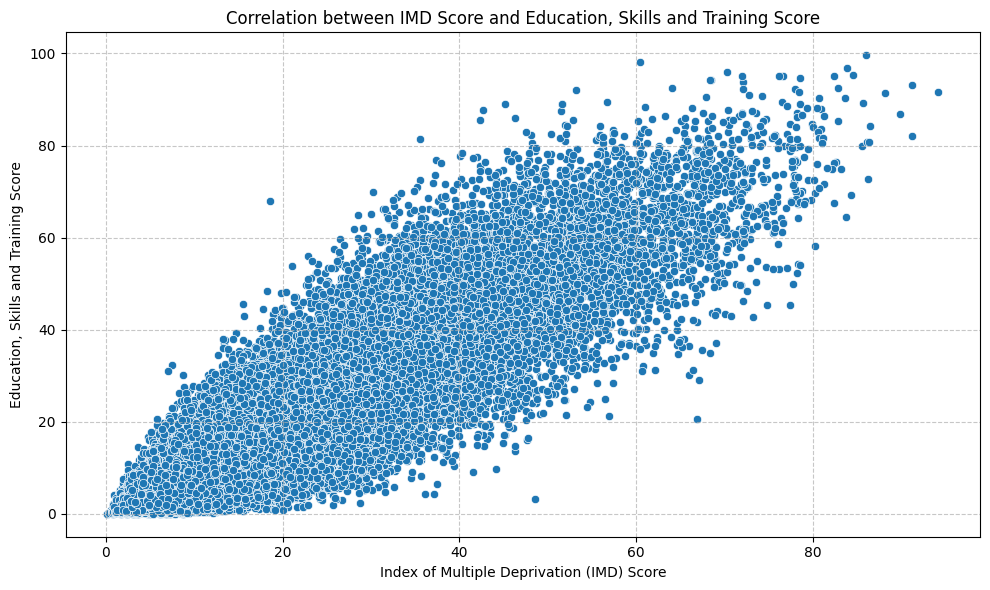

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=educatiom_imd_correlation, x='Index of Multiple Deprivation (IMD) Score', y='Education, Skills and Training Score')
plt.title('Correlation between IMD Score and Education, Skills and Training Score')
plt.xlabel('Index of Multiple Deprivation (IMD) Score')
plt.ylabel('Education, Skills and Training Score')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#how much each metric contribute to IMD
#Start Early
https://www.gov.uk/government/statistics/english-indices-of-deprivation-2025/english-indices-of-deprivation-2025-frequently-asked-questions#:~:text=There%20is%20not%20a%20definitive,described%20as%20'deprived').&text=Because%20there%20are%2033%2C755%20LSOAs,100/5=20).

#How likely to get away with punishment/Cost of Crime

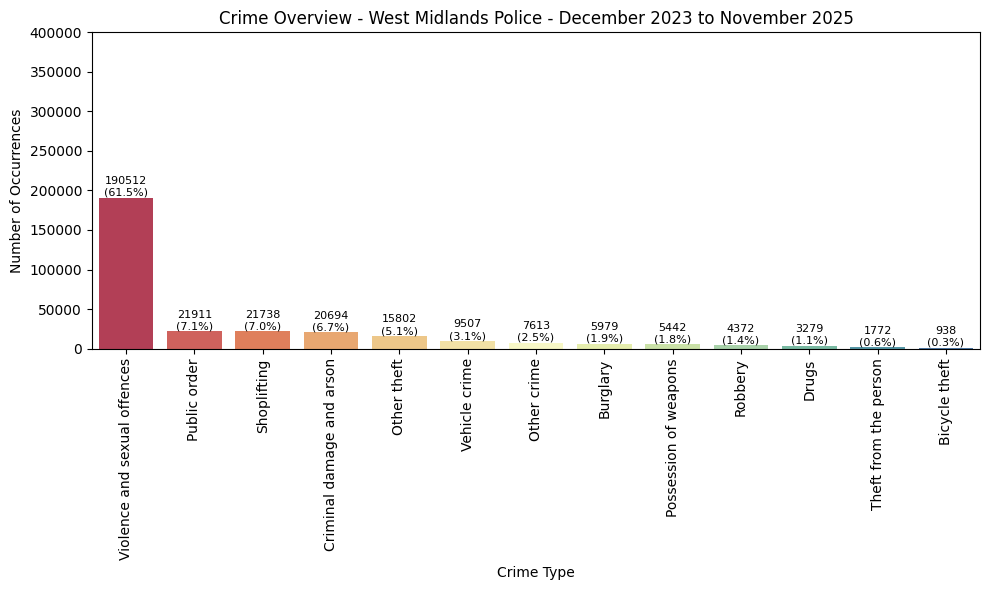

In [ ]:
#Bar Chart with percentages of total % For Crime Types
Outcome=['Unable to prosecute suspect']
Police=['West Midlands Police']
chart1=CleanData[CleanData['Reported by'].isin(Police) & CleanData['Last outcome category'].isin(Outcome)]
crime_type_counts = chart1['Crime type'].value_counts()
total_crimes = crime_type_counts.sum()
crime_type_percentages = (crime_type_counts / total_crimes * 100).round(1)

plt.figure(figsize=(10, 6))
sns.barplot(x=crime_type_counts.index, y=crime_type_counts.values, hue=crime_type_counts.index, palette='Spectral', legend=False)
plt.title('Crime Overview - West Midlands Police - December 2023 to November 2025')
plt.ylim(0, 400000)
plt.xlabel('Crime Type')
plt.ylabel('Number of Occurrences')
plt.xticks(rotation=90) # Rotate labels for better readability

# Add annotations for count and percentage
for index, value in enumerate(crime_type_counts.values):
    percentage = crime_type_percentages.iloc[index]
    plt.text(index, value + 50, f'{value}\n({percentage:.1f}%)', color='black', ha='center', va='bottom', fontsize=8)

# Adjust layout to prevent labels from being cut off
plt.tight_layout()
plt.show()

#AntiSocial does not have outcome recorded

In [ ]:
# First, filter DataMerge by the specified Outcome
filtered_data1 = DataMerge[DataMerge['Reported by'].isin(Police)]
filtered_data2 = DataMerge[DataMerge['Last outcome category'].isin(Outcome) & DataMerge['Reported by'].isin(Police)]
# Then, group the filtered data by 'Crime type' to get the counts
crime_counts_type1 = filtered_data1.groupby(['Crime type']).size().reset_index(name='CrimeCount')
crime_counts_type2 = filtered_data2.groupby(['Crime type']).size().reset_index(name='CrimeCount-Unproscuted')
unproscuted_rate=pd.merge(crime_counts_type1,crime_counts_type2,on='Crime type',how='left')
unproscuted_rate['unproscuted_rate%']=(unproscuted_rate['CrimeCount-Unproscuted']/unproscuted_rate['CrimeCount'].astype(float))*100
unproscuted_rate['unproscuted_rate%']=unproscuted_rate['unproscuted_rate%'].round(1)
unproscuted_rate.sort_values(by=["unproscuted_rate%"],ascending=False)

,Crime type,CrimeCount,CrimeCount-Unproscuted,unproscuted_rate%
13,Violence and sexual offences,266582,190512.0,71.5
8,Public order,37459,21911.0,58.5
5,Other crime,13209,7613.0,57.6
7,Possession of weapons,12946,5442.0,42.0
3,Criminal damage and arson,50311,20694.0,41.1
6,Other theft,41491,15802.0,38.1
10,Shoplifting,62492,21738.0,34.8
11,Theft from the person,5613,1772.0,31.6
9,Robbery,14162,4372.0,30.9
1,Bicycle theft,3822,938.0,24.5


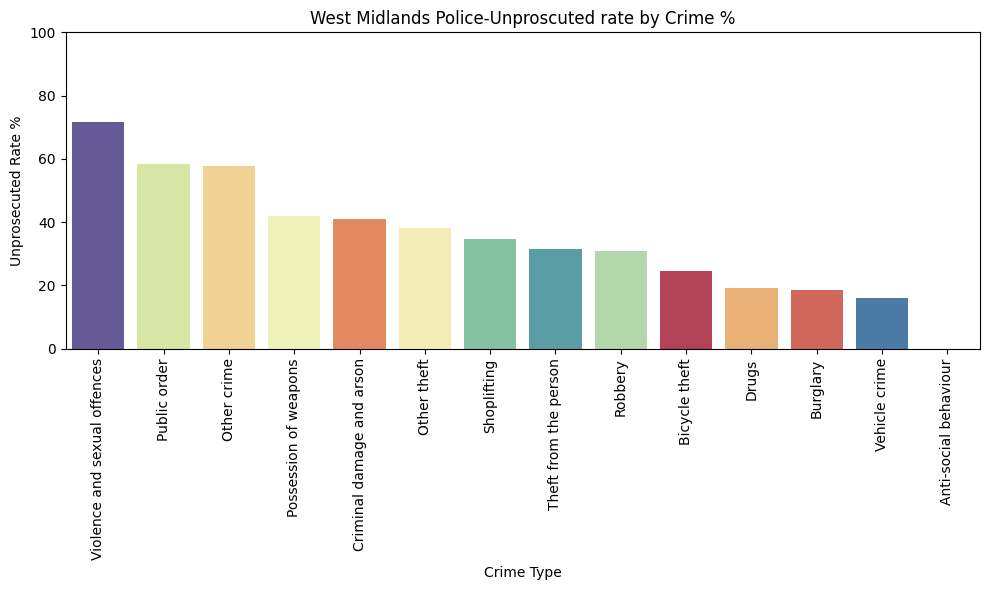

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(data=unproscuted_rate, x='Crime type', y='unproscuted_rate%', order=unproscuted_rate.sort_values(by='unproscuted_rate%', ascending=False)['Crime type'], hue=unproscuted_rate.index, palette='Spectral', legend=False)
plt.title('West Midlands Police-Unproscuted rate by Crime %')
plt.ylim(0, 100)
plt.xlabel('Crime Type')
plt.ylabel('Unprosecuted Rate %')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()